# Crowding backtest workbench

An implementable version of the Step 4 forecasts. Each hour the frozen OOS
forecast becomes a unit signal (`tail`: ±1 when |forecast| is in the training
top 20%; `continuous`: forecast / that threshold, clipped). The position is the
mean of the last H hourly signals, i.e. H staggered tranches each held H hours,
so overlapping trades net into one position.

Hourly P&L = position × next-hour perp return − position × funding settled that
hour − fee × |position change|. Fees per side: maker 2 bps (assumes passive
fills), taker 5 bps. Test period January 2023 to May 2026.

The primary variant (`all`, 24h, tail, 12-month window) was named before the run.
`baseline` and `baseline_positioning` were added afterwards for attribution.

In [1]:
from pathlib import Path
import json
import os

os.environ.setdefault('MPLCONFIGDIR', '/tmp/alpha-search-matplotlib')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import display
get_ipython().run_line_magic('matplotlib', 'inline')

REPO = Path('/Users/petermillington/Research/market-impact-research')
RESULTS = REPO / 'alpha-search' / 'reports' / 'crowding_backtest_v1'
config = json.loads(
    (REPO / 'alpha-search' / 'configs' / 'crowding_backtest_v1.json').read_text()
)
summary = pl.read_csv(RESULTS / 'backtest_summary.csv')
by_year = pl.read_csv(RESULTS / 'backtest_by_year.csv')
attribution = pl.read_csv(RESULTS / 'positioning_attribution.csv')
hourly = pl.read_parquet(RESULTS / 'backtest_hourly.parquet')

SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300']
INK, MUTED = '#2b2b2b', '#8a8a85'
MODELS = ['baseline', 'baseline_funding', 'baseline_basis', 'baseline_positioning', 'all']
MODEL_COLOUR = dict(zip(MODELS, SERIES))

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 115,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.color': '#e6e6e3',
    'lines.linewidth': 1.8,
})
pl.Config.set_tbl_rows(60)
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_width_chars(220)
pl.Config.set_float_precision(2)

polars.config.Config

## Manual controls

In [2]:
HORIZON = 24            # 8 or 24 hours
RULE = 'tail'           # 'tail' or 'continuous'
WINDOW = 12             # training window in months: 12 or 6
COST = 'maker'          # 'gross', 'maker' or 'taker'

assert HORIZON in config['horizons_hours']
assert RULE in config['position_rules']
assert WINDOW in config['training_windows_months']
assert COST in config['costs_bps_per_side']

## 1. Summary of all variants

In [3]:
summary.select(
    'model', 'horizon_hours', 'position_rule', 'training_window_months', 'primary',
    'mean_abs_position', 'turnover_per_day',
    f'{COST}_return_pct_per_year', f'{COST}_sharpe', f'{COST}_max_drawdown_pct',
    'recent_maker_return_pct_per_year', 'recent_maker_sharpe',
).sort(f'{COST}_sharpe', descending=True)

model,horizon_hours,position_rule,training_window_months,primary,mean_abs_position,turnover_per_day,maker_return_pct_per_year,maker_sharpe,maker_max_drawdown_pct,recent_maker_return_pct_per_year,recent_maker_sharpe
str,i64,str,i64,bool,f64,f64,f64,f64,f64,f64,f64
"""baseline_positioning""",8,"""tail""",12,false,0.23,0.60,35.48,1.66,-17.60,-5.13,-0.26
"""baseline_positioning""",8,"""continuous""",6,false,0.50,1.14,49.61,1.62,-32.38,30.95,1.03
"""all""",8,"""tail""",12,false,0.28,0.69,32.70,1.43,-17.00,0.30,0.02
"""baseline_positioning""",8,"""tail""",6,false,0.21,0.64,30.88,1.38,-20.72,8.25,0.36
"""baseline_positioning""",8,"""continuous""",12,false,0.53,1.02,40.83,1.34,-47.55,-14.39,-0.52
"""all""",8,"""continuous""",12,false,0.56,1.08,41.11,1.33,-39.26,-19.55,-0.76
"""all""",8,"""continuous""",6,false,0.53,1.18,37.46,1.24,-31.68,-1.12,-0.04
"""baseline_positioning""",24,"""continuous""",6,false,0.44,0.58,33.05,1.23,-26.98,36.05,1.34
"""all""",8,"""tail""",6,false,0.26,0.70,25.59,1.15,-30.68,-4.14,-0.19


## 2. Equity curves

Cumulative net P&L (percent of notional, not compounded) for the selected
horizon, rule and window. Buy-and-hold is on its own panel because its scale is
much larger.

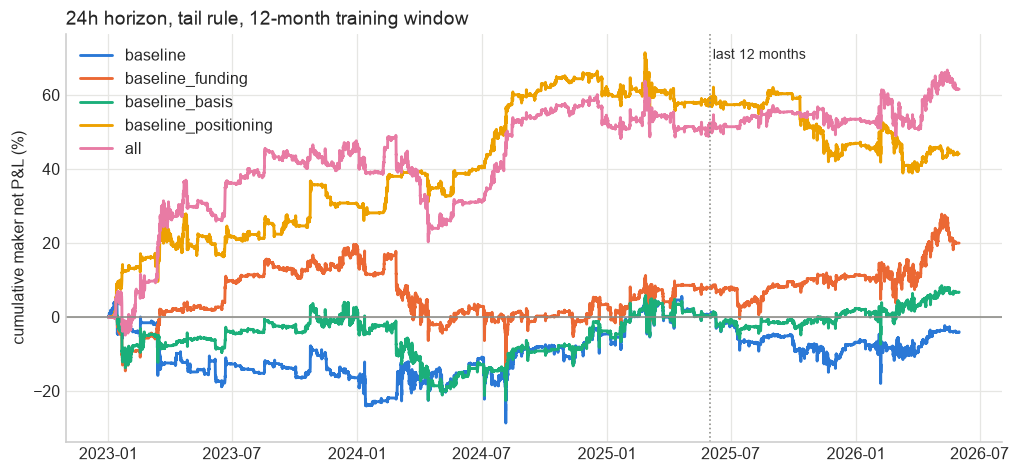

In [4]:
view = hourly.filter(
    (pl.col('horizon_hours') == HORIZON) & (pl.col('position_rule') == RULE)
    & (pl.col('training_window_months') == WINDOW)
)
fig, ax = plt.subplots(figsize=(10.5, 4.6))
for model in MODELS:
    series = view.filter(pl.col('model') == model).sort('time_s')
    if series.is_empty():
        continue
    equity = series[f'net_{COST}_bps'].cum_sum() / 100
    ax.plot(series.select(pl.from_epoch('time_s'))['time_s'], equity,
            color=MODEL_COLOUR[model], label=model)
ax.axhline(0, color=MUTED, linewidth=1)
ax.axvline(np.datetime64('2025-06-01'), color=MUTED, linestyle=':', linewidth=1)
ax.text(np.datetime64('2025-06-05'), ax.get_ylim()[1] * 0.95, 'last 12 months',
        fontsize=9, color=INK, va='top')
ax.set_ylabel(f'cumulative {COST} net P&L (%)')
ax.set_title(f'{HORIZON}h horizon, {RULE} rule, {WINDOW}-month training window', loc='left')
ax.legend(frameon=False, loc='upper left')
plt.show()

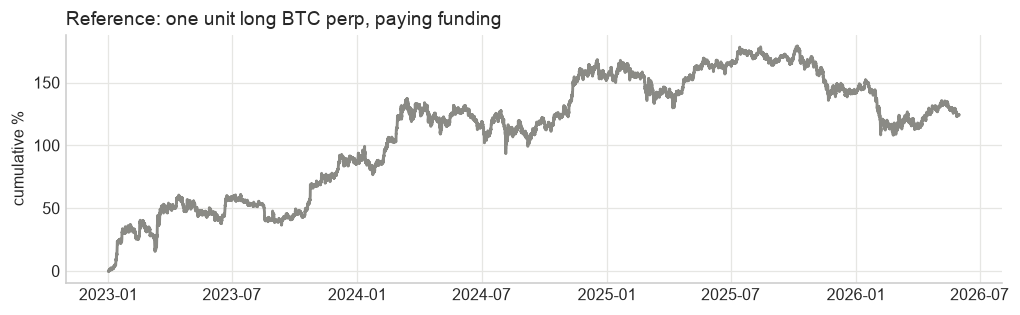

In [5]:
panel = pl.read_parquet(
    REPO / 'alpha-search' / 'reports' / 'funding_positioning_v1' / 'hourly_panel.parquet'
).filter(pl.col('time_s') >= view['time_s'].min()).sort('time_s')
long = (panel['F1h'].fill_nan(0.0) - panel['carry1h'].fill_nan(0.0)).cum_sum() / 100
fig, ax = plt.subplots(figsize=(10.5, 2.8))
ax.plot(panel.select(pl.from_epoch('time_s'))['time_s'], long, color=MUTED)
ax.set_ylabel('cumulative %')
ax.set_title('Reference: one unit long BTC perp, paying funding', loc='left')
plt.show()

## 3. Stability by year

In [6]:
by_year.filter(
    (pl.col('horizon_hours') == HORIZON) & (pl.col('position_rule') == RULE)
    & (pl.col('training_window_months') == WINDOW)
).pivot(on='year', index='model', values=f'{COST}_return_pct_per_year')

model,2023,2024,2025,2026
str,f64,f64,f64,f64
"""all""",46.71,6.77,-0.06,19.62
"""baseline""",-16.43,11.81,-2.27,6.92
"""baseline_basis""",1.80,-5.55,5.99,10.86
"""baseline_funding""",18.95,-15.46,7.93,20.78
"""baseline_positioning""",30.50,30.90,-14.56,-6.83


## 4. What drives it: drop-one attribution of the positioning group

`baseline_positioning`, tail rule, 12-month window. Each row removes one
positioning feature; the last removes all three long/short ratio features.

In [7]:
attribution

model,horizon_hours,dropped_feature,maker_return_pct_per_year,maker_sharpe,taker_sharpe
str,i64,str,f64,f64,f64
"""baseline_positioning""",8,"""none""",35.48,1.66,1.36
"""baseline_positioning""",8,"""oi_chg_1h""",36.71,1.72,1.42
"""baseline_positioning""",8,"""oi_chg_24h""",29.20,1.40,1.10
"""baseline_positioning""",8,"""oi_x_ret_24h""",35.18,1.67,1.36
"""baseline_positioning""",8,"""toptrader_ls_z30d""",26.06,1.33,1.00
"""baseline_positioning""",8,"""global_ls_z30d""",25.62,1.19,0.88
"""baseline_positioning""",8,"""taker_ls_1h""",39.45,1.82,1.52
"""baseline_positioning""",8,"""all_long_short_ratios""",2.37,0.12,-0.24
"""baseline_positioning""",24,"""none""",12.91,0.73,0.55


## Reading

See `alpha-search/reports/crowding-backtest-v1-initial-results.md`.